In [1]:
!pip install yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [3]:
# Plot Settings
sns.set_style('darkgrid')
matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 14

In [4]:
# 1. Load Stock Data
print("Downloading Apple (AAPL) stock data...")
df = yf.download('AAPL', start='2021-01-01', end='2024-01-01')

print("\nShape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

/tmp/ipykernel_9047/3038803064.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2021-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Shape: (753, 5)

First 5 Rows:
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-01-04  125.856705  129.941379  123.279466  129.853854  143301900
2021-01-05  127.412735  128.122701  124.903575  125.350950   97664900
2021-01-06  123.123863  127.451681  122.909903  124.213113  155088000
2021-01-07  127.325218  128.015730  124.349242  124.835513  109578200
2021-01-08  128.424210  128.988286  126.654176  128.793766  105158200

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 753 entries, 2021-01-04 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   753 non-null    float64
 1   (High, AAPL)    753 non-null    float64
 2   (Low, AAPL)     753 non-null    float64
 3   (Open, AAPL)    753 non-null    float64


In [5]:
# 2. Feature Engineering
# Use Open, High, Low, Volume to predict Close
df = df[['Open', 'High', 'Low', 'Volume', 'Close']].copy()
df.dropna(inplace=True)

X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

In [6]:
# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=42
)

print(f"\nTraining samples: {len(X_train)}, Testing samples: {len(X_test)}")


Training samples: 602, Testing samples: 151


In [7]:
# 4. Train Random Forest Model

print("\nTraining Random Forest model...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


Training Random Forest model...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(random_state=42)

In [8]:
# 5. Predictions & Evaluation
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"\nModel Evaluation:")
print(f"  MAE  : {mae:.2f}")
print(f"  RMSE : {rmse:.2f}")


Model Evaluation:
  MAE  : 7.48
  RMSE : 9.96


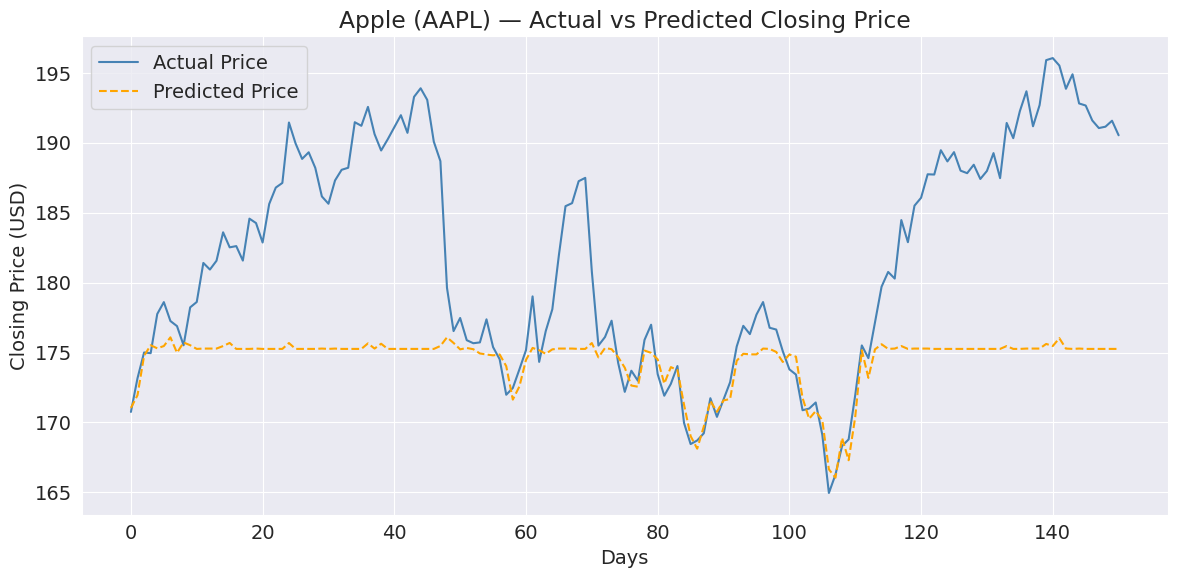

In [9]:
# 6. Plot Actual vs Predicted
plt.figure()
plt.plot(y_test.values, label='Actual Price', color='steelblue')
plt.plot(preds, label='Predicted Price', color='orange', linestyle='--')
plt.title('Apple (AAPL) — Actual vs Predicted Closing Price')
plt.xlabel('Days')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()


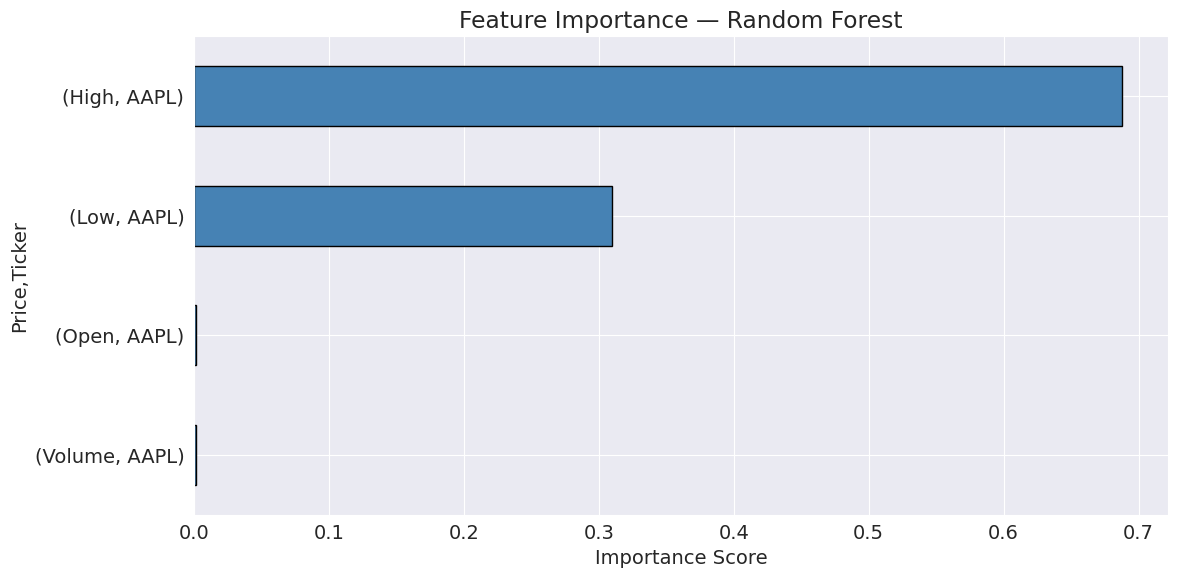

In [10]:
# 7. Feature Importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()